<a href="https://colab.research.google.com/github/AdityaWarrier2006/TensorFlow-for-Machine-Learning/blob/main/02_01_neural_network_classification_with_tensorflow_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Intro to neural network classigication using tensorflow


In [1]:
from sklearn.datasets import make_circles

# make 1000 examples
n_samples = 1000

# create circles
x, y = make_circles(n_samples,
                    noise = 0.03)

In [2]:
# check out the features
x # x is a 2D array that contains 2 coordinates

array([[ 1.00887725,  0.05520955],
       [-0.33151321, -0.91795955],
       [-0.54017017,  0.54197402],
       ...,
       [-0.70585131,  0.4734774 ],
       [ 0.03042587, -1.01064769],
       [ 0.64057662,  0.36402009]])

In [3]:
# check the labesl
y

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,

Visualizing our data

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":x[:,0], "x1":x[:,1], "label":y}) # x0 is the 1st element and x1 is the 2nd element
circles


,X0,x1,label
0,1.008877,0.055210,0
1,-0.331513,-0.917960,0
2,-0.540170,0.541974,1
3,0.983765,-0.259229,0
4,0.752604,0.289415,1
...,...,...,...
995,-0.648896,0.498249,1
996,-0.706762,0.340796,1
997,-0.705851,0.473477,1
998,0.030426,-1.010648,0


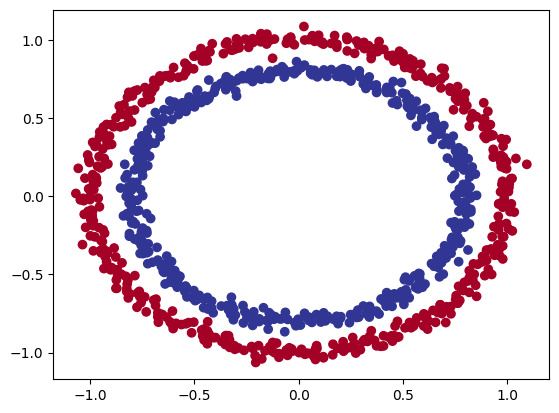

In [5]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0], x[:,1], c = y, cmap = plt.cm.RdYlBu)

# c = y is to color each dot based on its label in the y array
# RdYlBu: Stands for Red-Yellow-Blue.


In [6]:
x.shape, y.shape

((1000, 2), (1000,))

In [7]:
len(x), len(y)

(1000, 1000)

In [8]:
x[0], y[0]

(array([1.00887725, 0.05520955]), np.int64(0))

Build our Model

In [9]:
import tensorflow as tf

In [10]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model_1.compile(loss = ["BinaryCrossentropy"],
                optimizer = "SGD", # no square brackets since optimizer expects a single value not a list
                metrics = ["accuracy"]) # accuracy is: how many did we get right in a certain batch size
model_1.fit(x,y,epochs = 5, verbose = 0)

model_1.evaluate(x,y)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 8.0590


[8.059048652648926, 0.5]

In [11]:
# try improving by training for longer

model_1.fit(x,y, epochs=200,verbose =0)
model_1.evaluate(x,y) # ideally we evaluate using testing data not training data

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 8.0590


[8.059048652648926, 0.5]

In [12]:
# add an extra layer

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])
model_2.compile(loss = ["BinaryCrossentropy"],
                optimizer = "SGD", # no square brackets since optimizer expects a single value not a list
                metrics = ["accuracy"]) # accuracy is: how many did we get right in a certain batch size
model_2.fit(x,y,epochs = 200, verbose=0)

In [13]:
model_2.evaluate(x,y)

# despite adding a layer, accuracy has not improved

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6934


[0.6934000849723816, 0.5]

Improving our Model

In [14]:
'''
1. create a model - add, increase layers
2. compile - change optimizer (use adam?), change activisation funct, change learning_rate
3. fit - fit for longer
'''

'\n1. create a model - add, increase layers\n2. compile - change optimizer (use adam?), change activisation funct, change learning_rate\n3. fit - fit for longer\n'

In [15]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Create an Adam optimizer with a custom learning rate
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_3.compile(loss = "BinaryCrossentropy",
                optimizer = tf.keras.optimizers.Adam(), # Pass the optimizer object here
                metrics = ["accuracy"])

model_3.fit(x,y,epochs = 100, verbose=0)

In [16]:
model_3.evaluate(x,y)
# even with all these changes the model accuracy has not increased

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4960 - loss: 0.7008


[0.7008181810379028, 0.4959999918937683]

In [17]:
'''
create a meshgrid of the different X values
make predictions across the meshgrid
plot the model's predictions as well as the line between zones
'''

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# create our function
def plot_decision_boundary(model,x,y):
  # plots the decision boundary created by a model predicting on x.

  # define axis boundaries of plot and create meshgrid
  x_min, x_max = x[:, 0].min()-0.1, x[:,0].max()+0.1 # 0.1 is to have breathing room for the min and max points
  y_min, y_max = x[:, 1].min()-0.1, x[:,1].max()+0.1 # Corrected y_min, y_max to use x[:,1]

  # Create a meshgrid from both linspace arrays
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

  # create x values to make predictions on
  x_in = np.c_[xx.ravel(), yy.ravel()] # np.c_ is a shorthand for the actual funct

  # Make predictions (these will be logits since the last layer is Dense(1) without activation)
  y_pred = model.predict(x_in)

  # check for multi-class (multiple labes for a single input)
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
    # we have to reshape our predictions to get it ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  plot_data = y_pred

  # plot the decision boundary
  plt.contourf(xx,yy, plot_data.reshape(xx.shape), cmap = plt.cm.RdYlBu, alpha = 0.7)
  plt.scatter(x[:,0], x[:,1], c = y, s = 40, cmap = plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show() # Ensure plot is displayed

# Because your model only has linear layers, it can only draw a straight line through the data


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification


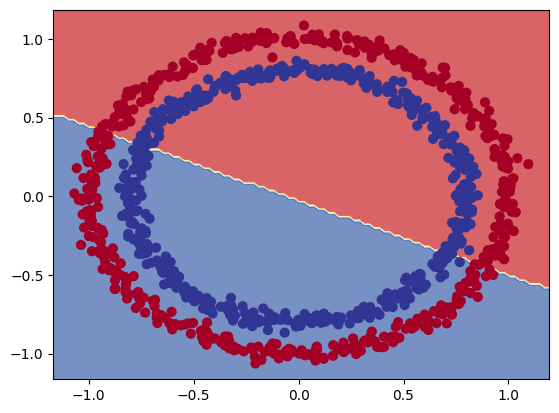

In [18]:
plot_decision_boundary(model_3, x, y=y)

In [19]:
# Let's see if our model can be used for a regression problem

# create data
x_regression = tf.range(0,1000,5)
y_regression = x_regression + 100

x_regression, y_regression

(<tf.Tensor: shape=(200,), dtype=int32, numpy=
 array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
         65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
        130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
        195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
        260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320,
        325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385,
        390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450,
        455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515,
        520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580,
        585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645,
        650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710,
        715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775,
        780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840,
    

In [20]:
# split into trining and test set
x_reg_train = x_regression[:150]
x_reg_test = x_regression[150:] # last 150 values

y_reg_train = y_regression[:150]
y_reg_test = y_regression[150:]

In [21]:
# Fit our model to the regression data

# model_3.fit(tf.expand_dims(x_reg_train), y_reg_train, epochs = 100)

### Model_3 was made with binary data in mind. It will not work when loss is set to BinaryCrossEntropy
### Make a new model with settigns loss to MAE

In [22]:
# similar to model_3 but with MAE as loss instead of BinaryCrossEntropy (BCE is for binary data)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[1]), # Explicitly set input_shape to (1,)
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Create an Adam optimizer with a custom learning rate
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_4.compile(loss = "MAE",
                optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01), # Pass the optimizer object here
                metrics = ["MAE"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# fit model_4
model_4.fit(tf.expand_dims(x_reg_train, axis = -1),y_reg_train,epochs = 100, verbose=0)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


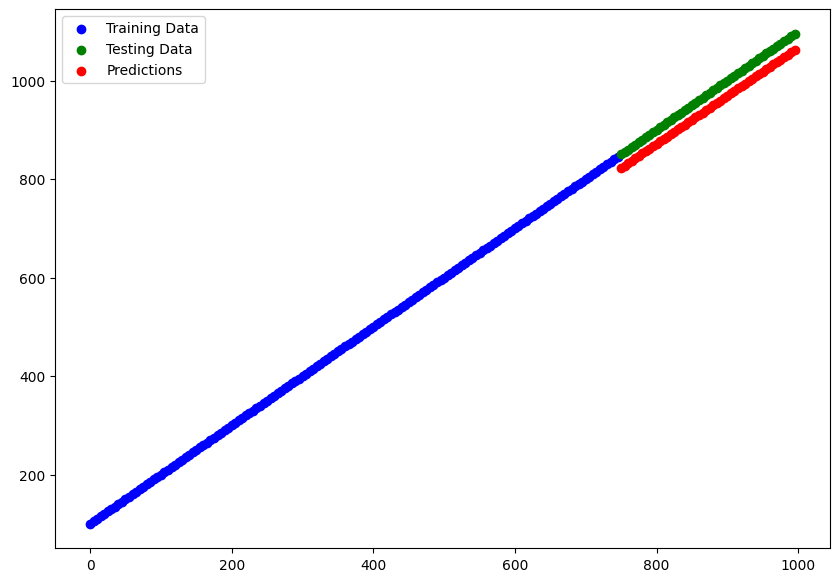

In [24]:
# Make predictions
y_reg_preds = model_4.predict(x_reg_test)

# pot the model's predictions
plt.figure(figsize = (10,7))
plt.scatter(x_reg_train, y_reg_train, c = "b", label = "Training Data")
plt.scatter(x_reg_test, y_reg_test, c = "g", label = "Testing Data")
plt.scatter(x_reg_test, y_reg_preds, c = "r", label = "Predictions")
plt.legend();


# Our model works for regression problem!
# => we need to introduce non-linearity to our model